In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the new dataset
df = pd.read_csv(r'C:\Users\sanya\OneDrive\Desktop\Projects\2. Business Intelligence\Data\Sales Transaction.csv')

# Check the data summary
print("Dataset Loaded Successfully!")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

df.head()

Dataset Loaded Successfully!
Total Rows: 536350
Total Columns: 8


,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,12/9/2019,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom
1,581475,12/9/2019,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom
2,581475,12/9/2019,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom
3,581475,12/9/2019,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom
4,581475,12/9/2019,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom


In [3]:
# Check which columns have missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Check for duplicate rows
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Missing values in each column:
TransactionNo     0
Date              0
ProductNo         0
ProductName       0
Price             0
Quantity          0
CustomerNo       55
Country           0
dtype: int64
Number of duplicate rows: 5200


In [4]:
# Convert Date column to proper datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Check if the change worked
print("Data types after conversion:")
print(df.dtypes['Date'])

Data types after conversion:
datetime64[us]


In [5]:
# Dropping rows where CustomerNo is NaN
df.dropna(subset=['CustomerNo'], inplace=True)

# Convert CustomerNo from float (12345.0) to int (12345) for better appearance
df['CustomerNo'] = df['CustomerNo'].astype(int)

print(f"Rows remaining after dropping nulls: {len(df)}")

Rows remaining after dropping nulls: 536295


In [6]:
# Removing the duplicates we found earlier
df.drop_duplicates(inplace=True)

print(f"Rows remaining after dropping duplicates: {len(df)}")

Rows remaining after dropping duplicates: 531095


In [7]:
# Keep only rows where Quantity and Price are greater than 0
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

print(f"Final clean row count: {len(df)}")

Final clean row count: 522601


In [8]:
# Create a Total_Sales column
df['Total_Sales'] = df['Quantity'] * df['Price']

# Let's see the first few rows of our clean, updated data
df.head()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,Total_Sales
0,581482,2019-12-09,22485,Set Of 2 Wooden Market Crates,21.47,12,17490,United Kingdom,257.64
1,581475,2019-12-09,22596,Christmas Star Wish List Chalkboard,10.65,36,13069,United Kingdom,383.40
2,581475,2019-12-09,23235,Storage Tin Vintage Leaf,11.53,12,13069,United Kingdom,138.36
3,581475,2019-12-09,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069,United Kingdom,127.80
4,581475,2019-12-09,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069,United Kingdom,71.64


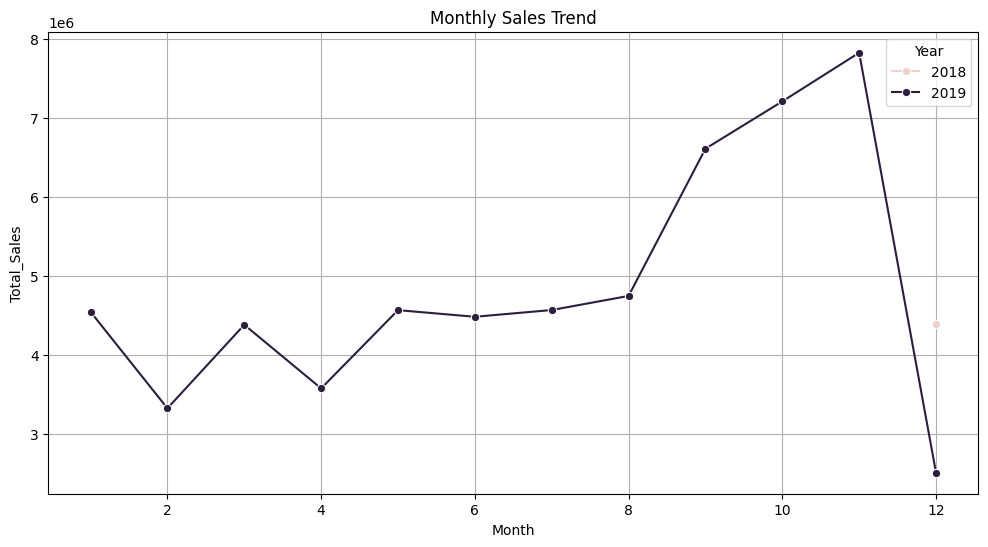

In [9]:
# Extracting Year and Month for analysis
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Grouping by Year and Month to see Sales Trend
monthly_sales = df.groupby(['Year', 'Month'])['Total_Sales'].sum().reset_index()

# Visualizing the trend
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_sales, x='Month', y='Total_Sales', hue='Year', marker='o')
plt.title('Monthly Sales Trend')
plt.grid(True)
plt.savefig(r'C:\Users\sanya\OneDrive\Desktop\Projects\2. Business Intelligence\Images\monthly_sales_trend.png', bbox_inches='tight')
plt.show()

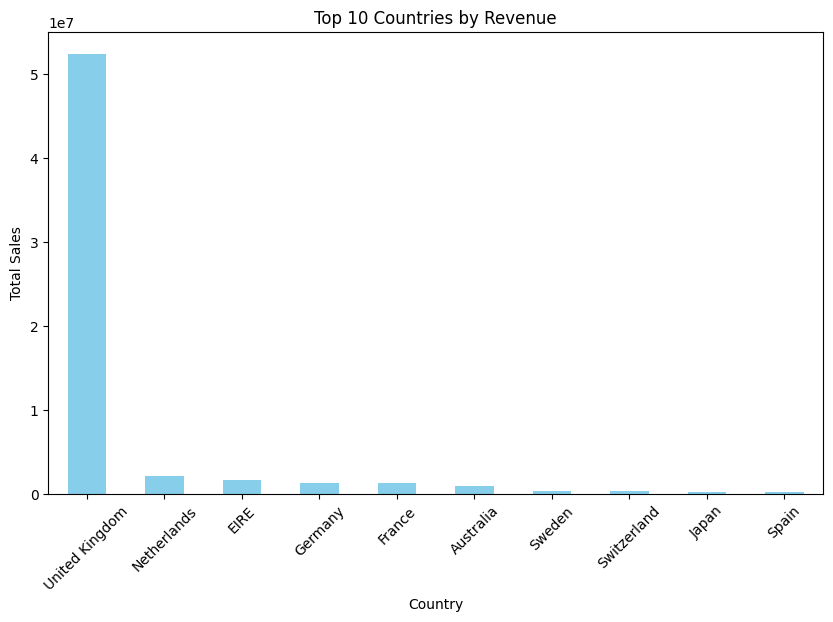

In [10]:
# Top 10 Countries by Sales
top_countries = df.groupby('Country')['Total_Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_countries.plot(kind='bar', color='skyblue')
plt.title('Top 10 Countries by Revenue')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.savefig(r'C:\Users\sanya\OneDrive\Desktop\Projects\2. Business Intelligence\Images\top_10_countries.png', bbox_inches='tight')
plt.show()

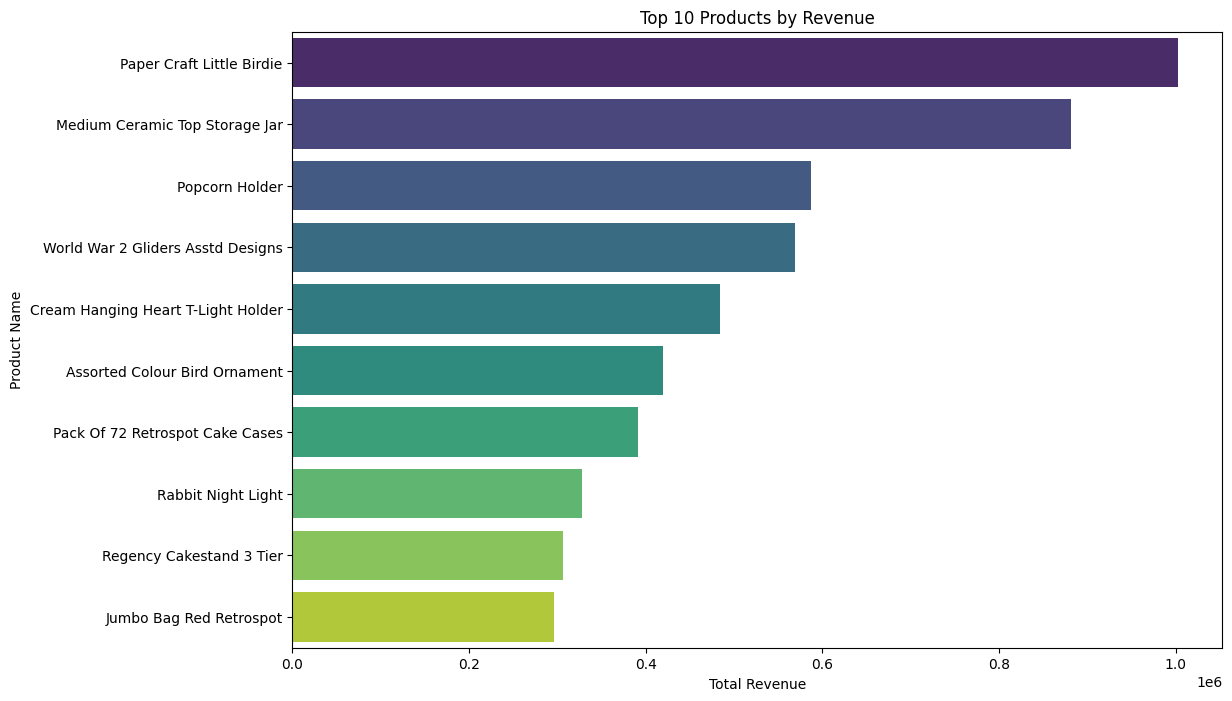

In [21]:
# Top 10 Products by Total Sales
top_products = df.groupby('ProductName')['Total_Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 8))
# Updated barplot to remove the warning
sns.barplot(
    x=top_products.values, 
    y=top_products.index, 
    hue=top_products.index,  # Add this line
    palette='viridis', 
    legend=False             # Add this to keep the graph clean
)
plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Product Name')

# SAVING THE GRAPH
plt.savefig(r'C:\Users\sanya\OneDrive\Desktop\Projects\2. Business Intelligence\Images\top_10_products.png', bbox_inches='tight')
plt.show()

In [13]:
# 1. Calculate Monetary (Total Spent per Customer)
customer_df = df.groupby('CustomerNo')['Total_Sales'].sum().reset_index()

# 2. Calculate Frequency (Total Transactions per Customer)
# We count unique TransactionNo to avoid counting every item as a new visit
frequency = df.groupby('CustomerNo')['TransactionNo'].nunique().reset_index()
frequency.columns = ['CustomerNo', 'Frequency']

# 3. Merge them together
customer_df = pd.merge(customer_df, frequency, on='CustomerNo')

# Rename columns for clarity
customer_df.columns = ['CustomerNo', 'Total_Spent', 'Frequency']

print("Customer-level data created for Machine Learning!")
customer_df.head()

Customer-level data created for Machine Learning!


,CustomerNo,Total_Spent,Frequency
0,12004,1509.60,1
1,12006,24.76,1
2,12008,5689.57,1
3,12013,69.96,1
4,12024,149.52,1


In [17]:
pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl (8.0 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl (36.5 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ------------------


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# 1. Prepare data for the model
# We create a simple 'Month_Index' (1, 2, 3...) because the model can't read dates
monthly_sales['Month_Index'] = range(1, len(monthly_sales) + 1)

X = monthly_sales[['Month_Index']] # Feature (The month number)
y = monthly_sales['Total_Sales']   # Target (The sales amount)

# 2. Split the data
# We use 80% to train the "brain" and 20% to test if it's right
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Create and Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Make Predictions
y_pred = model.predict(X_test)

# 5. Evaluate
error = mean_absolute_error(y_test, y_pred)
print(f"Model Training Complete!")
print(f"Average Error: ${error:.2f} (This is how much our predictions vary from reality)")

Model Training Complete!
Average Error: $1840425.26 (This is how much our predictions vary from reality)


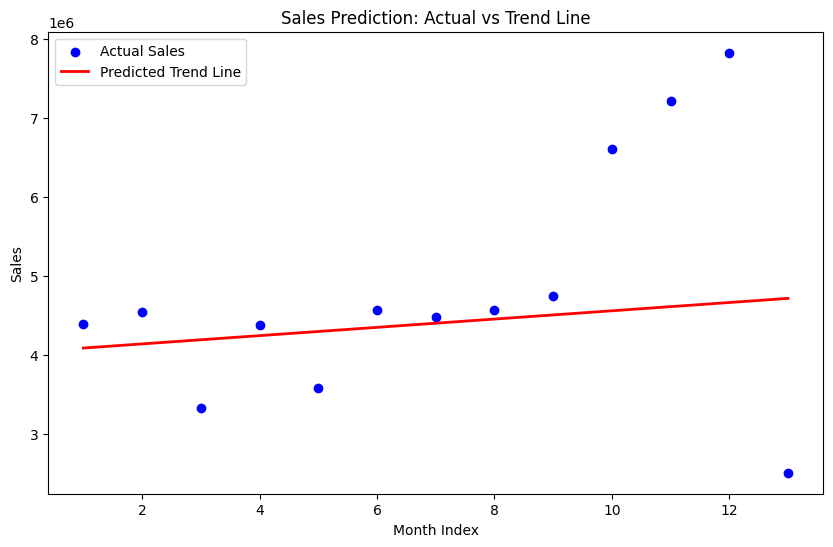

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Actual Sales')
plt.plot(X, model.predict(X), color='red', linewidth=2, label='Predicted Trend Line')
plt.title('Sales Prediction: Actual vs Trend Line')
plt.xlabel('Month Index')
plt.ylabel('Sales')
plt.legend()

# SAVING THE GRAPH
plt.savefig(r'C:\Users\sanya\OneDrive\Desktop\Projects\2. Business Intelligence\Images\sales_prediction_line.png', bbox_inches='tight')
plt.show()

In [22]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Select the features for clustering
# We use Spent and Frequency to group them
features = customer_df[['Total_Spent', 'Frequency']]

# 2. Scaling the data (CRITICAL STEP)
# K-Means is sensitive to the scale of numbers. 
# Since 'Total_Spent' is in the thousands and 'Frequency' is small, we must scale them.
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# 3. Apply K-Means
# Let's start by asking the model to find 3 groups (clusters)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_df['Cluster'] = kmeans.fit_predict(scaled_features)

print("Customer Segmentation Complete!")
customer_df.head()

Customer Segmentation Complete!


,CustomerNo,Total_Spent,Frequency,Cluster
0,12004,1509.60,1,0
1,12006,24.76,1,0
2,12008,5689.57,1,0
3,12013,69.96,1,0
4,12024,149.52,1,0


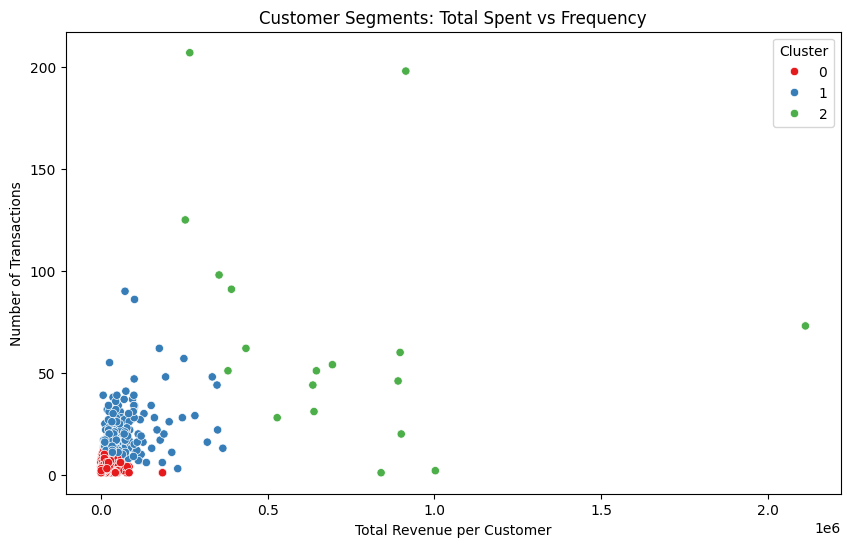

In [23]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=customer_df, 
    x='Total_Spent', 
    y='Frequency', 
    hue='Cluster', 
    palette='Set1'
)
plt.title('Customer Segments: Total Spent vs Frequency')
plt.xlabel('Total Revenue per Customer')
plt.ylabel('Number of Transactions')

# SAVING THE GRAPH
plt.savefig(r'C:\Users\sanya\OneDrive\Desktop\Projects\2. Business Intelligence\Images\customer_segments.png', bbox_inches='tight')
plt.show()

In [24]:
# 1. Merge the cluster info back into our main dataframe
# We join the 'Cluster' column from customer_df back to our main transactions
df = df.merge(customer_df[['CustomerNo', 'Cluster']], on='CustomerNo', how='left')

# 2. Save the final cleaned dataframe
df.to_csv(r'C:\Users\sanya\OneDrive\Desktop\Projects\2. Business Intelligence\Data\cleaned_transactions.csv', index=False)

# 3. Save the customer-level data (for clustering charts)
customer_df.to_csv(r'C:\Users\sanya\OneDrive\Desktop\Projects\2. Business Intelligence\Data\customer_segments_data.csv', index=False)

print("Project Data Saved! Ready for the Dashboard.")

Project Data Saved! Ready for the Dashboard.
